# Example 3 — Gaussian Mixture Model (GMM)

This notebook demonstrates Gaussian Mixture Model (GMM) clustering implemented with JAX, and visualises the fitting process with animations.

Goals:
- Introduce the GMM algorithm (E-step / M-step) at a high level.
- Show how to implement GMM steps in JAX for speed and reproducibility.
- Visualise the iterative fitting process and export animations to the `plots/` folder.

What you will see:
- Static plots of the generated dataset and final clustering result.
- An animation that shows how component means, covariances and responsibilities evolve over iterations.

Animation details and approach:
- We collect `history` during the fitting procedure: at each iteration we store the current means, covariances, weights and responsibilities.
- The animation function reads `history` and for each frame:
  - colours points by their current highest-responsibility component (soft colouring using responsibility magnitude),
  - draws component ellipses from the covariance matrices, and
  - marks component means with distinct markers.
- For performance and portability we save the animation to `plots/gmm_jax_animation.gif` (GIF via Pillow). If you need a higher-quality video, replace the writer with ffmpeg and export MP4.

Notes and prerequisites:
- This notebook uses JAX for numerical computation and `matplotlib` for plotting/animation.
- Ensure `pillow` is installed to save GIFs (`pip install pillow`).
- If you don't have JAX available, you can substitute the numeric code with equivalent NumPy implementations to run the visualisation logic.

Output location:
- All exported files are saved under `plots/` (relative to the notebook). This keeps generated artifacts in one place and makes it easy to share results. 

In [1]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from matplotlib.animation import FuncAnimation, PillowWriter
from jax import random
from IPython.display import Image
from matplotlib.patches import Ellipse
import jax.random as random
from pathlib import Path
# Set JAX to use CPU backend to avoid device placement issues
jax.config.update("jax_platform_name", "cpu")

# 1. K-means clustering

## Theory
K-means clustering partitions data into \(K\) clusters by minimising the within-cluster sum of squares. The algorithm alternates between two steps:
- Assignment step: assign each point to the nearest centroid (Euclidean distance).
- Update step: recompute centroids as the mean of points assigned to each cluster.


K-means finds a local minimum; initialization matters. Common strategies: random sampling of points, `k-means++`, or repeated restarts.


## Visualization
- We visualise the generated dataset and the final cluster assignments.
- The animation below shows centroid movement and decision boundaries across iterations: at each frame we plot points coloured by cluster assignment and draw a contour/mesh for decision regions.
- For reproducibility we fix the RNG seed and save exported figures to the `plots/` folder.

Usage tips:
- To speed up animation, reduce sample size or grid resolution for the decision boundary.
- To compare initialisations, run multiple seeds and visualise results side-by-side.

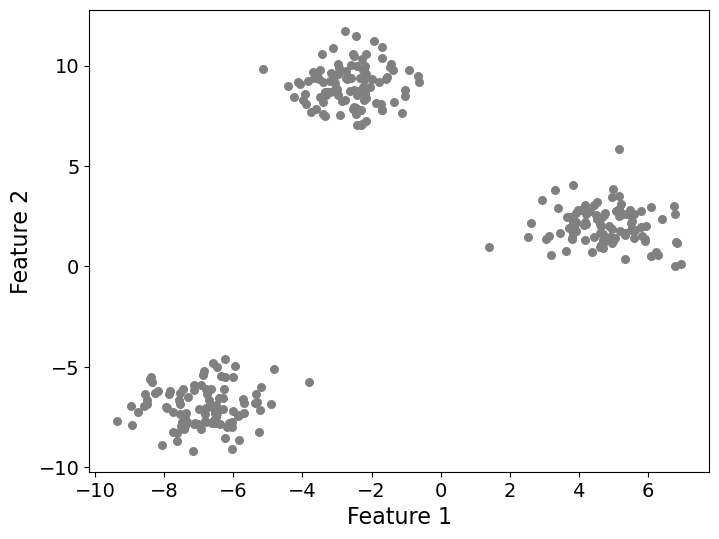

In [2]:
# Ensure plots directory exists (relative to notebook folder)
plot_dir = Path('..') / 'plots'
plot_dir.mkdir(parents=True, exist_ok=True)

# Generate synthetic dataset
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)
X = jnp.array(X)
plt.figure(figsize=(8, 6))
plt.scatter(np.array(X[:, 0]), np.array(X[:, 1]), c='gray', s=30)
#plt.title("Generated Data for K-means Clustering")
plt.xlabel("Feature 1", fontsize=16)
plt.ylabel("Feature 2", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 
plt.savefig(plot_dir / 'generated_data.png')
plt.show()

In [3]:
key = random.PRNGKey(42)
# Update centroids using masking
def compute_new_centroid(k, centroids, labels, X):
    mask = labels == k
    cluster_points = X * mask[:, None]
    cluster_sum = jnp.sum(cluster_points, axis=0)
    cluster_count = jnp.sum(mask)
    return jnp.where(cluster_count > 0, cluster_sum / cluster_count, centroids[k])


def kmeans_jax(X, n_clusters=3, max_iter=10, key=key):
    n_samples, n_features = X.shape
    # Randomly initialize centroids
    idx = jax.random.choice(key, n_samples, (n_clusters,), replace=False)
    centroids = X[idx]
    history = []

    for i in range(max_iter):
        # Compute distances and assign clusters
        dists = jnp.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = jnp.argmin(dists, axis=1)
        history.append((centroids, labels))

        # Update centroids using vmap
        new_centroids = jax.vmap(lambda k: compute_new_centroid(k, centroids, labels, X))(jnp.arange(n_clusters))

        # Check for convergence
        if jnp.all(jnp.linalg.norm(new_centroids - centroids, axis=1) < 1e-4):
            print(f"Converged after {i} iterations.")
            break
        centroids = new_centroids

    return centroids, labels, history

Converged after 2 iterations.


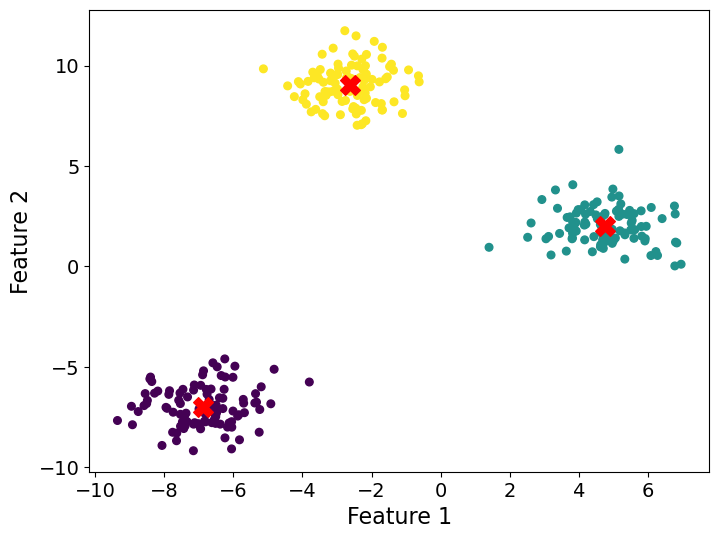

In [4]:
centroids, labels, history = kmeans_jax(X, n_clusters=3, max_iter=10, key=key)

plt.figure(figsize=(8, 6))
plt.scatter(np.array(X[:, 0]), np.array(X[:, 1]), c=np.array(labels), cmap='viridis', s=30)
plt.scatter(np.array(centroids[:, 0]), np.array(centroids[:, 1]), s=200, c='red', marker='X')
#plt.title("K-means Clustering with JAX")
plt.xlabel("Feature 1", fontsize=16)
plt.ylabel("Feature 2", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig(plot_dir / 'kmeans_result.png')
plt.show()

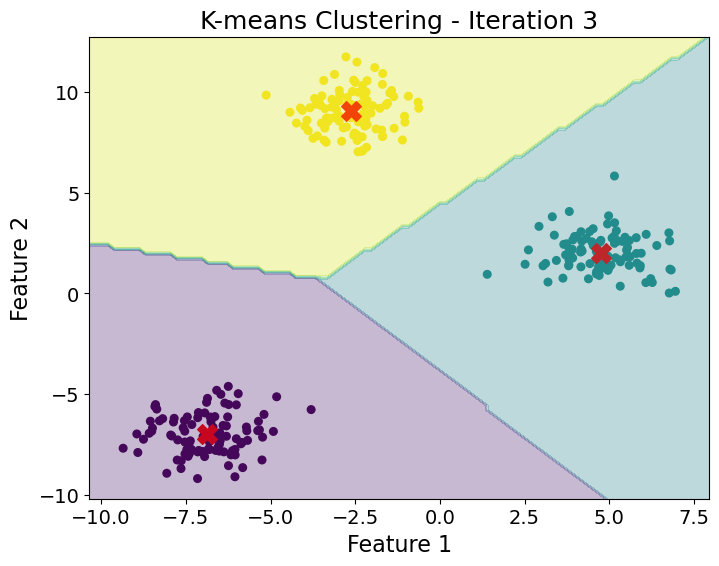

In [5]:
# Plotting the K-means clustering process with decision boundaries
fig, ax = plt.subplots(figsize=(8, 6))

# Initialize the scatter plot and centroid markers
scatter = ax.scatter(np.array(X[:, 0]), np.array(X[:, 1]), c='gray', s=30)
centroid_scatter = ax.scatter([], [], s=200, c='red', marker='X')

# Initialize the animation
def init():
    scatter.set_array(np.zeros(X.shape[0]))
    centroid_scatter.set_offsets(np.zeros((len(history[0][0]), 2)))
    return scatter, centroid_scatter

# Update function for the animation
def update(frame):
    centroids, labels = history[frame]
    ax.clear()
    scatter = ax.scatter(np.array(X[:, 0]), np.array(X[:, 1]), c=np.array(labels), cmap='viridis', s=30)
    centroid_scatter = ax.scatter(np.array(centroids[:, 0]), np.array(centroids[:, 1]), s=200, c='red', marker='X')
    
    # Create a mesh grid for decision boundaries
    x_min, x_max = np.array(X[:, 0]).min() - 1, np.array(X[:, 0]).max() + 1
    y_min, y_max = np.array(X[:, 1]).min() - 1, np.array(X[:, 1]).max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = jnp.c_[xx.ravel(), yy.ravel()]
    
    # Compute distances and assign clusters for the grid points
    dists = jnp.linalg.norm(grid[:, None, :] - centroids[None, :, :], axis=2)
    grid_labels = jnp.argmin(dists, axis=1)
    grid_labels = grid_labels.reshape(xx.shape)
    
    # Plot decision boundaries
    ax.contourf(xx, yy, np.array(grid_labels), alpha=0.3, cmap='viridis')
    
    ax.set_title(f"K-means Clustering - Iteration {frame + 1}", fontsize=18)
    ax.set_xlabel("Feature 1", fontsize=16)
    ax.set_ylabel("Feature 2", fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)
    return scatter, centroid_scatter

# Create the animation
ani = FuncAnimation(fig, update, frames=len(history), init_func=init, blit=False, interval=1000)

# Save the animation as a GIF
ani.save(plot_dir / "kmeans_animation_with_boundaries.gif", writer=PillowWriter(fps=2))


# 2. Gaussian Mixture Model (GMM) — Theory and Visualization

## Brief theory
A Gaussian Mixture Model represents the data distribution as a weighted sum of multivariate Gaussian components:
$$ p(x) = \sum_{k=1}^K w_k \; \mathcal{N}(x \mid \mu_k, \Sigma_k) $$
where $w_k$ are mixing weights, $\mu_k$ are means and $\Sigma_k$ are covariance matrices.

The EM algorithm alternates:
- E-step: compute responsibilities (posterior probability that each component generated each data point),
  $$ r_{nk} = \frac{w_k \; \mathcal{N}(x_n\mid\mu_k,\Sigma_k)}{\sum_j w_j \; \mathcal{N}(x_n\mid\mu_j,\Sigma_j)}. $$
- M-step: update parameters using responsibilities (weighted means, covariances, and weights).

EM maximises the data likelihood and returns soft assignments (probabilistic clustering). Initialization influences convergence and final solution.


## Visualization approach
- During fitting we record `history` = (means, covariances, weights, responsibilities) at each iteration.
- The animation visualises:
  - Points coloured by the component with highest responsibility (soft colouring intensity proportional to the maximum responsibility),
  - Ellipses representing 1-sigma contours of component covariances, and
  - Component means marked with a large `X` marker.
- Saving: the animation cell writes a GIF to `plots/gmm_jax_animation.gif`. To produce a video, swap the writer to `FFMpegWriter` and save MP4.

Practical tips:
- If covariances become singular, regularise by adding a small diagonal term (e.g., `1e-6 * I`).
- For numerical stability and speed in JAX, prefer batched operations and avoid Python loops where possible.
- If JAX isn't available, the same visualization logic works with NumPy arrays and the recorded `history`. 

In [6]:
class GMMVisualizerJAX:
    """
    Gaussian Mixture Model clustering with visualization of the process using JAX.
    """
    def __init__(self, X, n_components=3, max_iter=10, key=None):
        self.X = X
        self.n_components = n_components
        self.max_iter = max_iter
        self.n_samples, self.n_features = X.shape
        if key is None:
            key = random.PRNGKey(0)
        idx = random.choice(key, self.n_samples, (n_components,), replace=False)
        self.means = X[idx]
        self.covariances = jnp.stack([jnp.cov(X.T)] * n_components)
        self.weights = jnp.ones(n_components) / n_components
        self.responsibilities = jnp.zeros((self.n_samples, n_components))
        self.history = []

    def multivariate_normal_pdf(self, X, mean, cov):
        """Compute multivariate normal pdf for all X."""
        n = X.shape[1]
        diff = X - mean
        inv_cov = jnp.linalg.inv(cov)
        det_cov = jnp.linalg.det(cov)
        norm_const = 1.0 / (jnp.power((2 * jnp.pi), n / 2) * jnp.sqrt(det_cov))
        exp_term = jnp.exp(-0.5 * jnp.sum(diff @ inv_cov * diff, axis=1))
        return norm_const * exp_term

    def e_step(self):
        """E-step: update responsibilities."""
        pdfs = []
        for k in range(self.n_components):
            pdfs.append(self.weights[k] * self.multivariate_normal_pdf(self.X, self.means[k], self.covariances[k]))
        pdfs = jnp.stack(pdfs, axis=1)
        responsibilities = pdfs / jnp.sum(pdfs, axis=1, keepdims=True)
        self.responsibilities = responsibilities
        self.history.append((
            self.means.copy(), 
            self.covariances.copy(), 
            self.weights.copy(), 
            self.responsibilities.copy()
        ))

    def m_step(self):
        """M-step: update means, covariances, weights."""
        N_k = jnp.sum(self.responsibilities, axis=0)
        self.weights = N_k / self.n_samples
        self.means = (self.responsibilities.T @ self.X) / N_k[:, None]
        covariances = []
        for k in range(self.n_components):
            diff = self.X - self.means[k]
            weighted = diff.T * self.responsibilities[:, k]
            cov = weighted @ diff / N_k[k]
            covariances.append(cov)
        self.covariances = jnp.stack(covariances)

    def fit(self):
        for _ in range(self.max_iter):
            self.e_step()
            self.m_step()

    def animate(self, filename="gmm_jax_animation.gif"):
        fig, ax = plt.subplots(figsize=(8, 6))

        def plot_ellipse(mean, cov, ax, color):
            vals, vecs = np.linalg.eigh(np.array(cov))
            order = vals.argsort()[::-1]
            vals, vecs = vals[order], vecs[:, order]
            theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
            width, height = 2 * np.sqrt(vals)
            ellipse = Ellipse(mean, width, height, theta, edgecolor=color, lw=2, facecolor='none')
            ax.add_patch(ellipse)

        def update(frame):
            ax.clear()
            means, covariances, weights, responsibilities = self.history[frame]
            resp_colors = np.argmax(np.array(responsibilities), axis=1)
            max_resp = np.max(np.array(responsibilities), axis=1)
            # Color by responsibility (soft coloring)
            colors = sns.color_palette("viridis", self.n_components)
            point_colors = np.array([colors[i] for i in resp_colors])
            ax.scatter(np.array(self.X[:, 0]), np.array(self.X[:, 1]), c=point_colors, s=30, alpha=max_resp)
            for k in range(self.n_components):
                # Fix: Ellipse expects (xy, width, height, angle) as keywords, not as positional arguments
                mean = means[k]
                width, height = 2 * np.sqrt(np.linalg.eigvalsh(covariances[k]))
                # Compute the angle of the ellipse from the eigenvectors of the covariance matrix
                eigvals, eigvecs = np.linalg.eigh(np.array(covariances[k]))
                order = eigvals.argsort()[::-1]
                eigvals, eigvecs = eigvals[order], eigvecs[:, order]
                theta = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
                color = colors[k]
                ellipse = Ellipse(xy=mean, width=width, height=height, angle=theta, edgecolor=color, lw=2, facecolor='none')
                ax.add_patch(ellipse)
                ax.scatter(means[k][0], means[k][1], c=[colors[k]], s=200, marker='X', edgecolor='k')
            ax.set_title(f"Gaussian Mixture Model - Iteration {frame + 1}", fontsize=18)
            ax.set_xlabel("Feature 1", fontsize=16)
            ax.set_ylabel("Feature 2", fontsize=16)
            ax.tick_params(axis='both', which='major', labelsize=14)

            ax.set_xlim(np.array(self.X[:, 0]).min() - 2, np.array(self.X[:, 0]).max() + 2)
            ax.set_ylim(np.array(self.X[:, 1]).min() - 2, np.array(self.X[:, 1]).max() + 2)
            ax.tick_params(axis='both', which='major', labelsize=14)

        ani = FuncAnimation(fig, update, frames=len(self.history), interval=1000, blit=False)
        ani.save(filename, writer=PillowWriter(fps=2))
        plt.close(fig)
        return filename

# Usage:
gmm_vis = GMMVisualizerJAX(X, n_components=3, max_iter=20, key=key)
gmm_vis.fit()
gmm_vis.animate(plot_dir / "gmm_jax_animation.gif")

PosixPath('../plots/gmm_jax_animation.gif')

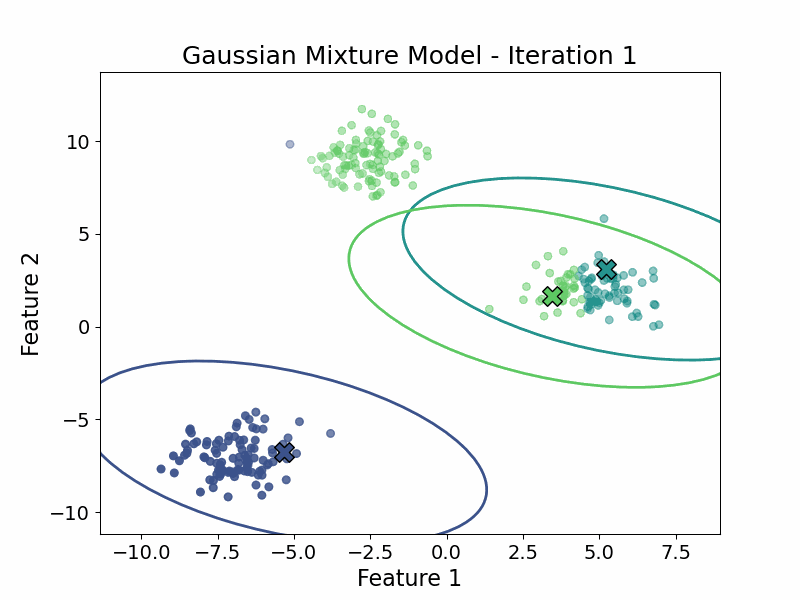

In [7]:
Image(filename=plot_dir / "gmm_jax_animation.gif")